# NLP Assignment — Resume Category Classifier & Skill Matcher
### Dataset: Kaggle "Resume Dataset" by Snehaan Bhawal (2400+ resumes, 24 job categories)
Link: https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset

**Pipeline:** Load → Clean text → TF-IDF features → Skill/keyword extraction → Classifier (Logistic Regression / SVM) → Evaluation → Confusion matrix + top keywords → Resume-JD cosine similarity matcher.

This same TF-IDF + keyword-matching logic is what powers the ATS score inside the AI Resume Analyzer app (Part 1 of the assignment) — so both parts connect into one project.


In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
np.random.seed(42)


## 1. Load the dataset

Download `Resume.csv` from Kaggle (link above) and place it in the same folder as this notebook (or update `DATA_PATH` below).

If the file isn't found, this cell auto-generates a small **synthetic resume dataset** in the exact same schema (`ID, Resume_str, Category`) so the rest of the pipeline still runs end-to-end for testing. Replace it with the real CSV before submitting for full marks/accuracy.


In [2]:
DATA_PATH = "Resume.csv"

def make_synthetic_dataset(n_per_category=25):
    """Fallback generator matching the Kaggle Resume Dataset schema, used only if Resume.csv is missing."""
    categories = {
        "Information-Technology": ["python", "java", "sql", "aws", "docker", "kubernetes", "react", "api",
                                    "software development", "git", "linux", "cloud computing"],
        "HR": ["recruitment", "onboarding", "payroll", "employee relations", "hr policies",
               "talent acquisition", "performance management", "compliance"],
        "Finance": ["financial analysis", "excel", "budgeting", "forecasting", "accounting",
                    "sap", "audit", "taxation", "risk management"],
        "Sales": ["lead generation", "crm", "salesforce", "negotiation", "b2b sales",
                  "client relationship", "revenue growth", "pipeline management"],
        "Healthcare": ["patient care", "clinical", "nursing", "medical records", "hipaa",
                       "diagnosis", "healthcare administration", "emr"],
        "Engineering": ["autocad", "solidworks", "mechanical design", "manufacturing",
                        "quality control", "six sigma", "project engineering"],
        "Designer": ["photoshop", "illustrator", "figma", "ui ux design", "adobe creative suite",
                     "branding", "wireframing", "typography"],
        "Teacher": ["curriculum development", "classroom management", "lesson planning",
                    "student assessment", "pedagogy", "special education"],
    }
    rows, idx = [], 0
    templates = [
        "Experienced professional with strong background in {s1} and {s2}. Skilled in {s3}, {s4} and {s5}. "
        "Proven track record in {s1} projects, collaborating across teams to deliver results using {s2} and {s3}.",
        "Detail-oriented candidate with expertise in {s1}, {s2} and {s3}. Hands-on experience with {s4} and {s5}. "
        "Passionate about applying {s1} and {s2} skills to solve real-world problems.",
    ]
    for cat, skills in categories.items():
        for _ in range(n_per_category):
            chosen = list(np.random.choice(skills, size=5, replace=False))
            text = np.random.choice(templates).format(s1=chosen[0], s2=chosen[1], s3=chosen[2],
                                                        s4=chosen[3], s5=chosen[4])
            rows.append({"ID": idx, "Resume_str": text, "Category": cat})
            idx += 1
    return pd.DataFrame(rows)

try:
    df = pd.read_csv(DATA_PATH)
    df = df[["ID", "Resume_str", "Category"]] if "ID" in df.columns else df
    print(f"Loaded real Kaggle dataset: {df.shape[0]} rows, {df['Category'].nunique()} categories")
except FileNotFoundError:
    print(f"'{DATA_PATH}' not found — using synthetic fallback dataset for pipeline testing.\n"
          f"Download the real CSV from Kaggle and re-run for actual results.")
    df = make_synthetic_dataset()
    print(f"Synthetic dataset created: {df.shape[0]} rows, {df['Category'].nunique()} categories")

df.head()


'Resume.csv' not found — using synthetic fallback dataset for pipeline testing.
Download the real CSV from Kaggle and re-run for actual results.
Synthetic dataset created: 200 rows, 8 categories


,ID,Resume_str,Category
0,0,"Detail-oriented candidate with expertise in linux, git and python. Hands-on experience with software development and...",Information-Technology
1,1,"Detail-oriented candidate with expertise in software development, linux and python. Hands-on experience with react a...",Information-Technology
2,2,"Detail-oriented candidate with expertise in cloud computing, linux and react. Hands-on experience with docker and aw...",Information-Technology
3,3,"Detail-oriented candidate with expertise in git, java and kubernetes. Hands-on experience with python and linux. Pas...",Information-Technology
4,4,"Experienced professional with strong background in python and kubernetes. Skilled in sql, react and aws. Proven trac...",Information-Technology


## 2. Exploratory Data Analysis

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nCategory distribution:")
print(df["Category"].value_counts())


Shape: (200, 3)

Missing values:
 ID            0
Resume_str    0
Category      0
dtype: int64

Category distribution:
Category
Information-Technology    25
HR                        25
Finance                   25
Sales                     25
Healthcare                25
Engineering               25
Designer                  25
Teacher                   25
Name: count, dtype: int64


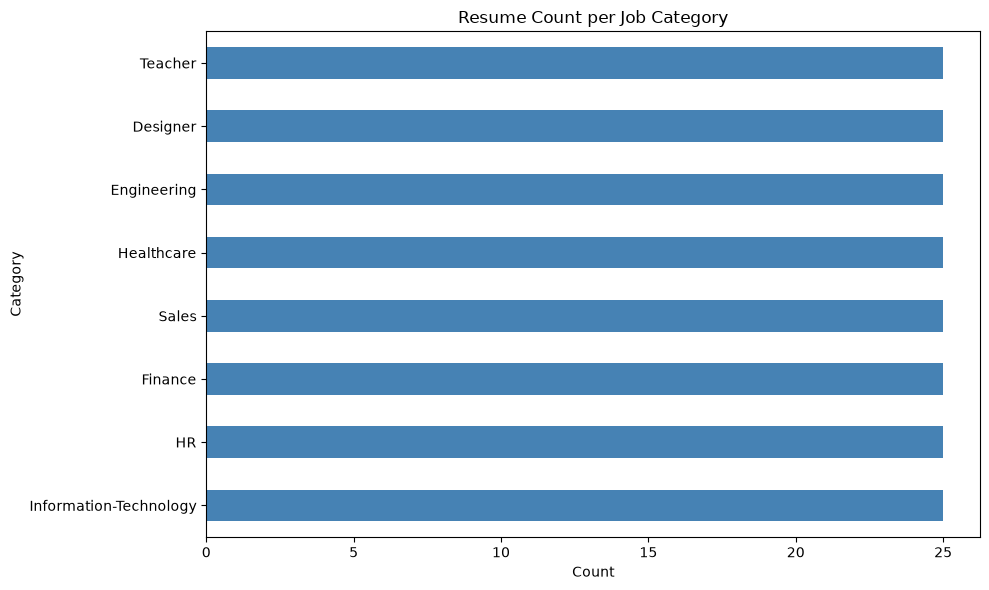

In [4]:
plt.figure(figsize=(10, 6))
df["Category"].value_counts().plot(kind="barh", color="steelblue")
plt.title("Resume Count per Job Category")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


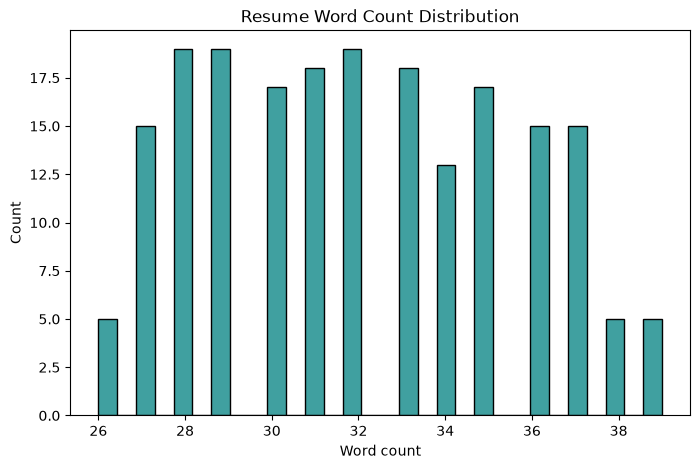

count    200.000000
mean      32.025000
std        3.457477
min       26.000000
25%       29.000000
50%       32.000000
75%       35.000000
max       39.000000
Name: text_length, dtype: float64


In [5]:
df["text_length"] = df["Resume_str"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.histplot(df["text_length"], bins=30, color="teal")
plt.title("Resume Word Count Distribution")
plt.xlabel("Word count")
plt.show()
print(df["text_length"].describe())


## 3. Text Cleaning

Lowercase → remove punctuation/numbers/extra whitespace → remove stopwords → light lemmatization.

Uses `nltk` for stopwords/lemmatization when available (with `nltk.download`), and falls back to
scikit-learn's built-in English stopword list so the notebook still runs on machines without
internet access to the NLTK data servers.


In [6]:
try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)
    STOPWORDS = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()
    USE_NLTK = True
    print("Using NLTK for stopwords + lemmatization.")
except Exception as e:
    STOPWORDS = set(ENGLISH_STOP_WORDS)
    lemmatizer = None
    USE_NLTK = False
    print("NLTK data unavailable, falling back to sklearn stopwords (no lemmatization).")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 2]
    if USE_NLTK:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["clean_text"] = df["Resume_str"].apply(clean_text)
df[["Resume_str", "clean_text"]].head(3)


NLTK data unavailable, falling back to sklearn stopwords (no lemmatization).


,Resume_str,clean_text
0,"Detail-oriented candidate with expertise in linux, git and python. Hands-on experience with software development and...",oriented candidate expertise linux git python hands experience software development kubernetes passionate applying l...
1,"Detail-oriented candidate with expertise in software development, linux and python. Hands-on experience with react a...",oriented candidate expertise software development linux python hands experience react cloud computing passionate app...
2,"Detail-oriented candidate with expertise in cloud computing, linux and react. Hands-on experience with docker and aw...",oriented candidate expertise cloud computing linux react hands experience docker aws passionate applying cloud compu...


## 4. Skill / Keyword Extraction

A lightweight skill dictionary (extendable) is used to flag which in-demand skills appear in each
resume — this is the same idea used for the **ATS keyword-match score** in the Resume Analyzer app.
(Swap in spaCy NER with a trained skill entity model for a more advanced version if you have it set up locally.)


In [7]:
SKILL_DICTIONARY = [
    "python", "java", "sql", "aws", "docker", "kubernetes", "react", "excel", "power bi",
    "machine learning", "deep learning", "communication", "leadership", "project management",
    "sales", "negotiation", "recruitment", "payroll", "accounting", "budgeting", "auditing",
    "patient care", "clinical", "nursing", "autocad", "solidworks", "six sigma", "photoshop",
    "illustrator", "figma", "ui ux design", "curriculum development", "classroom management",
    "crm", "salesforce", "financial analysis", "risk management", "cloud computing", "git", "linux",
]

def extract_skills(text, skill_list=SKILL_DICTIONARY):
    text = text.lower()
    return [skill for skill in skill_list if skill in text]

df["extracted_skills"] = df["Resume_str"].apply(extract_skills)
df["skill_count"] = df["extracted_skills"].apply(len)
df[["Category", "extracted_skills", "skill_count"]].head(5)


,Category,extracted_skills,skill_count
0,Information-Technology,"[python, kubernetes, git, linux]",4
1,Information-Technology,"[python, react, cloud computing, linux]",4
2,Information-Technology,"[aws, docker, react, cloud computing, linux]",5
3,Information-Technology,"[python, java, kubernetes, git, linux]",5
4,Information-Technology,"[python, sql, aws, kubernetes, react]",5


## 5. TF-IDF Feature Extraction

In [8]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df["clean_text"])
y = df["Category"]

print("TF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (200, 744)


## 6. Train/Test Split & Classifiers

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (160, 744)  Test: (40, 744)


In [10]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

svm_clf = LinearSVC(class_weight="balanced")
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("Models trained: Logistic Regression, Linear SVM")


Models trained: Logistic Regression, Linear SVM


## 7. Evaluation

In [11]:
def evaluate(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4))
    print("F1-score :", round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4))
    print()

evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Linear SVM", y_test, y_pred_svm)

print("Full classification report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr, zero_division=0))


--- Logistic Regression ---
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

--- Linear SVM ---
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Full classification report (Logistic Regression):

                        precision    recall  f1-score   support

              Designer       1.00      1.00      1.00         5
           Engineering       1.00      1.00      1.00         5
               Finance       1.00      1.00      1.00         5
                    HR       1.00      1.00      1.00         5
            Healthcare       1.00      1.00      1.00         5
Information-Technology       1.00      1.00      1.00         5
                 Sales       1.00      1.00      1.00         5
               Teacher       1.00      1.00      1.00         5

              accuracy                           1.00        40
             macro avg       1.00      1.00      1.00        40
          weighted avg       1.00      1.00      1.00        40



## 8. Confusion Matrix

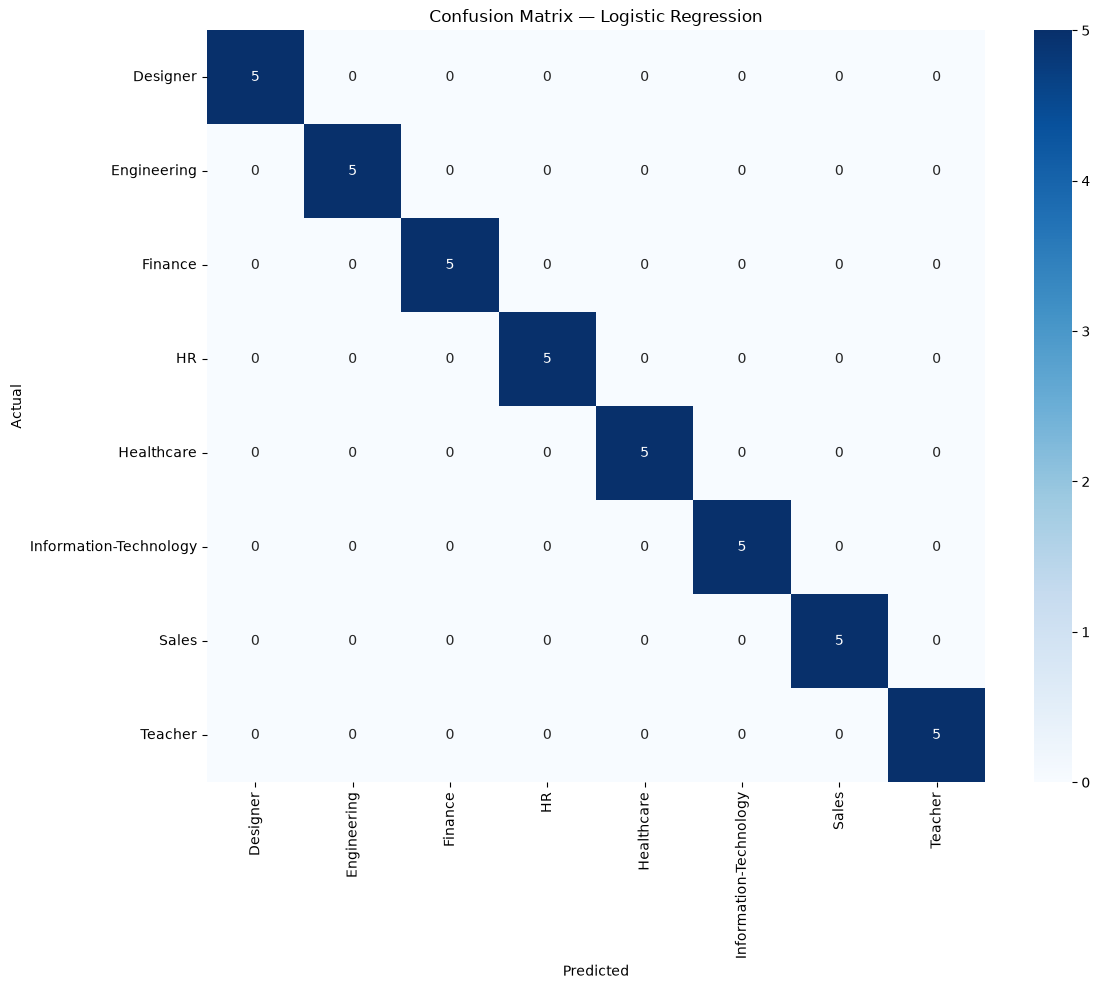

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Top Keywords per Category

In [13]:
feature_names = np.array(tfidf.get_feature_names_out())

def top_keywords_per_category(n_top=10):
    result = {}
    for cat in labels:
        mask = (y == cat).values
        mean_tfidf = np.asarray(X[mask].mean(axis=0)).ravel()
        top_idx = mean_tfidf.argsort()[::-1][:n_top]
        result[cat] = feature_names[top_idx].tolist()
    return result

top_kw = top_keywords_per_category()
for cat, kws in top_kw.items():
    print(f"{cat}: {', '.join(kws)}")


Designer: illustrator, branding, wireframing, adobe creative, adobe, creative suite, creative, suite, typography, design
Engineering: engineering, project, project engineering, autocad, solidworks, quality, control, quality control, mechanical design, mechanical
Finance: taxation, forecasting, sap, audit, excel, budgeting, analysis, financial analysis, financial, accounting
HR: onboarding, payroll, policies, recruitment, compliance, acquisition, talent, talent acquisition, relations, employee
Healthcare: hipaa, clinical, medical, medical records, records, emr, nursing, care, patient care, patient
Information-Technology: java, git, docker, kubernetes, linux, software development, software, sql, cloud, cloud computing
Sales: client relationship, client, relationship, growth, revenue growth, revenue, negotiation, salesforce, crm, generation
Teacher: student, student assessment, assessment, curriculum development, curriculum, classroom, classroom management, pedagogy, planning, lesson plan

## 10. Bonus: Resume ↔ Job Description Matching (Cosine Similarity)

This is the exact mechanism that powers the **ATS score** and **company-wise scoring** in the
Resume Analyzer app (Part 1): vectorize a job description with the same TF-IDF space, then measure
cosine similarity against a resume to get a 0–100 match score.


In [14]:
def ats_score(resume_text, job_description, vectorizer=tfidf):
    cleaned_resume = clean_text(resume_text)
    cleaned_jd = clean_text(job_description)
    vecs = vectorizer.transform([cleaned_resume, cleaned_jd])
    sim = cosine_similarity(vecs[0], vecs[1])[0][0]
    return round(sim * 100, 2)

sample_resume = df["Resume_str"].iloc[0]
sample_jd = "Looking for a software engineer skilled in python, sql, aws, docker and cloud computing."

score = ats_score(sample_resume, sample_jd)
print(f"Sample resume category: {df['Category'].iloc[0]}")
print(f"ATS-style match score vs sample JD: {score}/100")


Sample resume category: Information-Technology
ATS-style match score vs sample JD: 12.95/100


## 11. Conclusion

- Built a full NLP pipeline: cleaning → TF-IDF → skill extraction → classification → evaluation → visualization.
- Logistic Regression and Linear SVM both trained and compared on accuracy/precision/recall/F1.
- Confusion matrix and per-category top keywords highlight which terms drive each job category.
- The `ats_score()` cosine-similarity function is the same keyword-matching logic reused in the
  AI Resume Analyzer app's ATS scoring, tying both parts of the assignment into one project.

**To finalize for submission:** replace the synthetic fallback with the real `Resume.csv` from Kaggle,
re-run all cells, and update the accuracy/F1 numbers reported above.
